# 05. Primera ronda controlada de mejoras

**Autor:** Marco Padilla Gómez. **Issue:** [#48](https://github.com/maarcoopg/tfg-ml-financial-sentiment/issues/48).

Este experimento separa cinco decisiones: depuración de noticias repetidas, duración del entrenamiento, representación del sentimiento, criterio de selección y amplitud de búsqueda. Conserva los experimentos anteriores y no presupone que cada cambio mejore la predicción.

La ejecución `first-round-full-20260916` utiliza las mismas cuatro empresas y fechas externas ya examinadas. **Es una evaluación exploratoria, no un conjunto nuevo de prueba.** No descarga datos ni modifica los resultados. El [protocolo](../docs/first_round_protocol.md) fija las comparaciones y el [informe](../reports/experiments/first-round-full-20260916/analysis.md) interpreta sus resultados.

In [1]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
from IPython.display import display, Markdown
from sklearn.metrics import roc_auc_score

ROOT = Path.cwd()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
RUN = ROOT / 'reports/experiments/first-round-full-20260916'
manifest = json.loads((RUN / 'manifest.json').read_text(encoding='utf-8'))
assert manifest['status'] == 'complete'
prefix = RUN.relative_to(ROOT).as_posix() + '/'
for path, digest in manifest['output_sha256'].items():
    if path.startswith(prefix):
        assert hashlib.sha256((ROOT / path).read_bytes()).hexdigest() == digest, path
macro = pd.read_csv(RUN / 'metrics/macro_metrics.csv')
companies = pd.read_csv(RUN / 'metrics/company_metrics.csv')
folds = pd.read_csv(RUN / 'metrics/all_metrics.csv')
intervals = pd.read_csv(RUN / 'metrics/paired_intervals.csv')
selected = pd.read_csv(RUN / 'tuning/selected_params.csv')
cv = pd.read_csv(RUN / 'tuning/inner_cv.csv')
predictions = pd.read_csv(RUN / 'predictions/all_predictions.csv', parse_dates=['Date'], float_precision='round_trip')
coverage = pd.read_csv(RUN / 'quality/monthly_coverage.csv')
sources = pd.read_csv(RUN / 'quality/monthly_sources.csv')
stages = ['reference', 'deduplicated', 'window_3y', 'window_5y', 'enhanced', 'macro', 'tuned']
names = dict(zip(stages, ['Referencia', 'Deduplicación', 'Ventana 3 años', 'Ventana 5 años', 'Sentimiento enriquecido', 'Selección macro', 'Ajuste ampliado']))
variants = {'base': 'Base', 'hybrid': 'Híbrido', 'lag_1': 'Con retardo'}
models = {'logistic_regression': 'Regresión logística', 'random_forest': 'Bosque aleatorio', 'hist_gradient_boosting': 'Potenciación por histogramas'}
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
display(pd.Series({'Modelos externos': len(selected), 'Ajustes internos': len(cv), 'Predicciones': len(predictions), 'Intervalos pareados': len(intervals)}).to_frame('Recuento'))

,Recuento
Modelos externos,210
Ajustes internos,2214
Predicciones,154840
Intervalos pareados,315


## 1. Qué se compara y por qué

La referencia es el modelo conjunto con **variables relativas sin identificador de empresa**. No es el modelo original con niveles absolutos. Se conservan tres algoritmos prefijados: regresión logística, bosque aleatorio y potenciación por histogramas. Los promedios entre algoritmos de este cuaderno no deben compararse con promedios de cinco algoritmos de otras ejecuciones.

| Etapa | Cambio | Referencia para aislarlo |
| --- | --- | --- |
| Deduplicación | Conservar el primer título normalizado idéntico por empresa en 24 horas | Referencia |
| Ventanas 3/5 años | Limitar el entrenamiento en cada frontera | Deduplicación |
| Sentimiento enriquecido | Intensidad, desacuerdo y sorpresas históricas | Deduplicación |
| Selección macro | Optimizar AUC medio dentro de empresas | Enriquecido |
| Ajuste ampliado | Más hiperparámetros y elección interna de ventana | Selección macro |

La comparación principal es **ajuste ampliado menos referencia para el híbrido de cada algoritmo**. La etapa final combina cambios, por lo que su diferencia no identifica por sí sola una causa.

## 2. Cobertura y repeticiones

La deduplicación normaliza Unicode, mayúsculas y espacios; conserva números, signos y negaciones. Nunca utiliza registros futuros para cambiar una decisión anterior. No pretende identificar toda equivalencia semántica: un titular idéntico también puede acompañar una actualización válida. Por eso se conserva el corpus original y se trata la depuración como una hipótesis experimental.

Las proporciones siguientes describen **noticias registradas**, no cobertura certificada del proveedor. Las tablas mensuales se restringen a las sesiones del panel financiero.

,Auditoría
original_records,46014
retained_records,42734
removed_records,3280
policy,first identical NFKC/casefold/whitespace-norma...
coverage_verified,False
semantic_duplicates_removed,False


ticker,AAPL,MSFT,NVDA,TSLA
year,,,,
2016,1,0,0,1
2017,1,2,0,0
2018,3,1,1,1
2019,2,1,6,0
2020,7,7,4,1
2021,10,5,5,7
2022,6,8,14,4
2023,9,8,6,2
2024,10,12,24,8


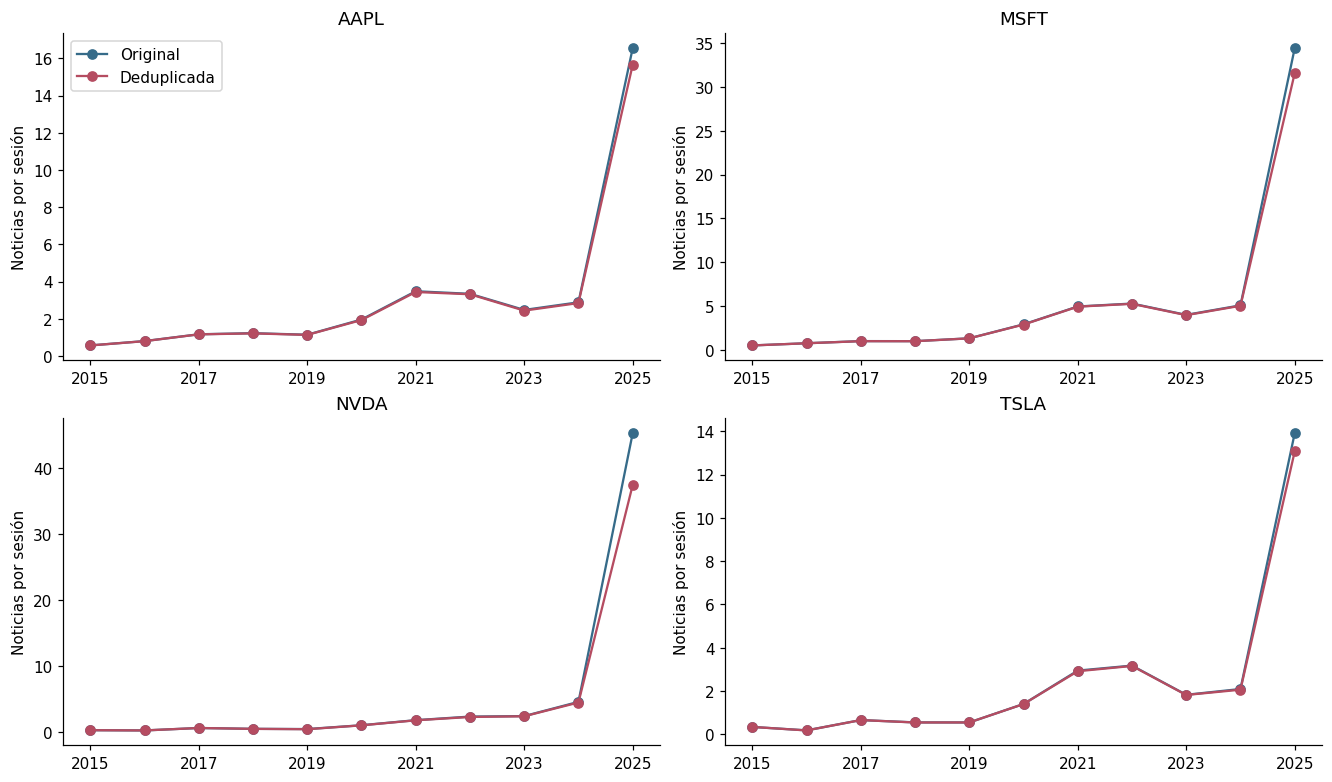

,year,source,news
294,2024,Yahoo Finance,51
155,2024,MarketBeat,48
164,2024,Morningstar,41
219,2024,SiliconANGLE,37
274,2024,TradingView,36
785,2025,MarketWatch,1181
783,2025,MarketBeat,763
1052,2025,The Globe and Mail,645
1197,2025,Yahoo Finance,397
707,2025,Investing.com,392


In [2]:
display(pd.Series(manifest['quality_audit']).to_frame('Auditoría'))
removed = pd.read_csv(RUN / 'quality/removed_by_year.csv')
display(removed.pivot(index='year', columns='ticker', values='removed_records').fillna(0).astype(int))
coverage['year'] = coverage.month.str[:4].astype(int)
annual = coverage.groupby(['approach', 'ticker', 'year'])[['news', 'sessions', 'recorded_days']].sum().reset_index()
annual['news_per_session'] = annual.news / annual.sessions
fig, axes = plt.subplots(2, 2, figsize=(12, 7), layout='constrained')
for ax, ticker in zip(axes.flat, ['AAPL', 'MSFT', 'NVDA', 'TSLA']):
    for approach, label, color in [('original', 'Original', '#366b89'), ('deduplicated', 'Deduplicada', '#b54c61')]:
        view = annual[(annual.ticker == ticker) & (annual.approach == approach)]
        ax.plot(view.year, view.news_per_session, marker='o', label=label, color=color)
    ax.set_title(ticker)
    ax.set_ylabel('Noticias por sesión')
    ax.set_xticks([2015, 2017, 2019, 2021, 2023, 2025])
axes[0, 0].legend()
plt.show()
display(sources[(sources.ticker == 'NVDA') & sources.month.str.startswith(('2024', '2025')) & (sources.approach == 'original')]
        .assign(year=lambda x: x.month.str[:4]).groupby(['year', 'source']).news.sum().reset_index()
        .sort_values(['year', 'news'], ascending=[True, False]).groupby('year').head(5))

## 3. Variables y controles temporales

La base relativa conserva nueve variables financieras y **ninguna noticia**. El híbrido de referencia tiene 22 y el de retardo 24. El enriquecido añade desviación típica del tono, intensidad absoluta, sorpresa respecto a la media histórica, disponibilidad de historia y sorpresa del volumen logarítmico de noticias. Sus tamaños son 27 y 34, respectivamente; este último incluye cinco retardos nuevos.

Las referencias históricas excluyen la sesión actual. La media de tono utiliza únicamente días con noticias dentro de las veinte sesiones previas, con un mínimo de cinco observaciones. La sorpresa de volumen se limita a [−5; 5] y vale cero sin variación histórica suficiente. Estas convenciones son parte de la hipótesis, no parámetros escogidos tras observar la prueba.

Las ventanas se aplican por separado a cada entrenamiento interno y externo. Las fechas de validación permanecen iguales. Cuando aún no hay tres o cinco años de historia, solo se utiliza el pasado disponible.

In [3]:
feature_counts = pd.DataFrame({name: {variants[v]: len(cols) for v, cols in schema.items()} for name, schema in manifest['feature_sets'].items()})
display(feature_counts.rename(columns={'original': 'Original', 'clean': 'Deduplicada', 'enhanced': 'Enriquecida'}))
assert (pd.to_datetime(cv.train_target_end) < pd.to_datetime(cv.valid_start)).all()
assert (pd.to_datetime(selected.train_target_end) < pd.to_datetime(selected.valid_start)).all()
for years in [3, 5]:
    window = cv[cv.window_years.astype(str) == str(years)]
    assert (pd.to_datetime(window.train_start) >= pd.to_datetime(window.valid_start).map(lambda d: d - pd.DateOffset(years=years))).all()
display(selected[['approach', 'outer_fold', 'window_years', 'train_start', 'train_end', 'train_target_end', 'valid_start', 'valid_end', 'train_rows']].drop_duplicates())

,Original,Deduplicada,Enriquecida
Base,9,9,9
Híbrido,22,22,27
Con retardo,24,24,34


,approach,outer_fold,window_years,train_start,train_end,train_target_end,valid_start,valid_end,train_rows
0,reference,1,all,2015-01-02,2023-10-12,2023-10-13,2023-10-16,2024-07-11,8840
10,reference,2,all,2015-01-02,2024-07-10,2024-07-11,2024-07-12,2025-04-04,9580
20,reference,3,all,2015-01-02,2025-04-03,2025-04-04,2025-04-07,2025-12-29,10316
30,deduplicated,1,all,2015-01-02,2023-10-12,2023-10-13,2023-10-16,2024-07-11,8840
40,deduplicated,2,all,2015-01-02,2024-07-10,2024-07-11,2024-07-12,2025-04-04,9580
50,deduplicated,3,all,2015-01-02,2025-04-03,2025-04-04,2025-04-07,2025-12-29,10316
60,window_3y,1,all,2015-01-02,2023-10-12,2023-10-13,2023-10-16,2024-07-11,8840
61,window_3y,1,3,2020-10-16,2023-10-12,2023-10-13,2023-10-16,2024-07-11,3008
70,window_3y,2,all,2015-01-02,2024-07-10,2024-07-11,2024-07-12,2025-04-04,9580
71,window_3y,2,3,2021-07-12,2024-07-10,2024-07-11,2024-07-12,2025-04-04,3016


## 4. Comparación de AUC macro

Primero se calcula AUC dentro de cada empresa y después la media de las cuatro, con igual peso. La tabla y figura siguientes promedian además los tres algoritmos como **resumen descriptivo, no como modelo adicional**. La media por bloque temporal y el AUC del panel agrupado son métricas distintas.

Un AUC de 0,53 no significa acertar el 53 %. La línea de 0,5 indica falta de discriminación en AUC, no una predicción de rentabilidad.

approach,Referencia,Deduplicación,Ventana 3 años,Ventana 5 años,Sentimiento enriquecido,Selección macro,Ajuste ampliado
dataset_type,,,,,,,
Base,0.5039,0.5039,0.4970,0.5023,0.5039,0.5039,0.4995
Híbrido,0.5080,0.5056,0.4951,0.5039,0.5046,0.5046,0.5015
Con retardo,0.5040,0.5079,0.4979,0.5070,0.5007,0.5007,0.4996


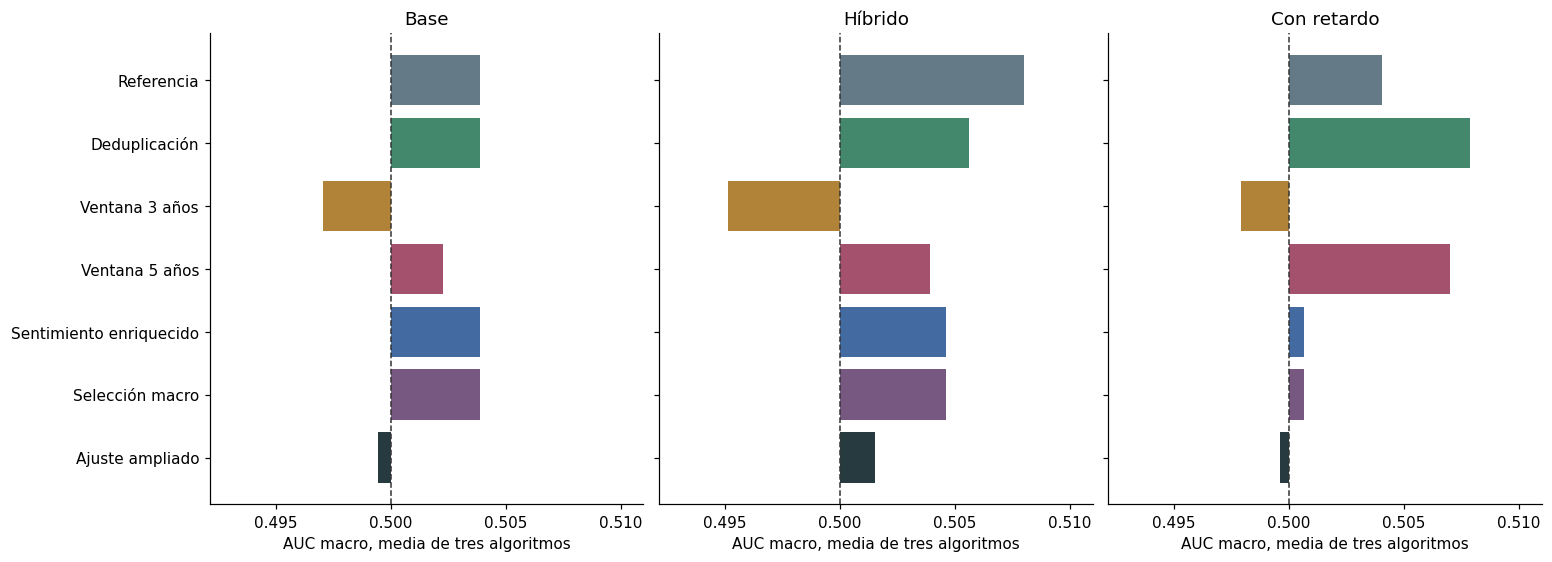

approach                                   Referencia  Deduplicación  \
dataset_type model_name                                                
Base         Potenciación por histogramas      0.5030         0.5030   
             Regresión logística               0.5019         0.5019   
             Bosque aleatorio                  0.5068         0.5068   
Híbrido      Potenciación por histogramas      0.5127         0.5147   
             Regresión logística               0.5000         0.4977   
             Bosque aleatorio                  0.5112         0.5045   
Con retardo  Potenciación por histogramas      0.5024         0.5172   
             Regresión logística               0.4998         0.4974   
             Bosque aleatorio                  0.5099         0.5090   

approach                                   Ventana 3 años  Ventana 5 años  \
dataset_type model_name                                                     
Base         Potenciación por histogramas          0.4981          0.5029   
             Regresión logística                   0.4902          0.4940   
             Bosque aleatorio                      0.5028          0.5099   
Híbrido      Potenciación por histogramas          0.4944          0.5055   
             Regresión logística                   0.4870          0.4980   
             Bosque aleatorio                      0.5040          0.5082   
Con retardo  Potenciación por histogramas          0.5052          0.5149   
             Regresión logística                   0.4856          0.4985   
             Bosque aleatorio                      0.5029          0.5077   

approach                                   Sentimiento enriquecido  \
dataset_type model_name                                              
Base         Potenciación por histogramas                   0.5030   
             Regresión logística                            0.5019   
             Bosque aleatorio                               0.5068   
Híbrido      Potenciación por histogramas                   0.5066   
             Regresión logística                            0.4971   
             Bosque aleatorio                               0.5101   
Con retardo  Potenciación por histogramas                   0.4991   
             Regresión logística                            0.4960   
             Bosque aleatorio                               0.5068   

approach                                   Selección macro  Ajuste ampliado  
dataset_type model_name                                                      
Base         Potenciación por histogramas           0.5030           0.5008  
             Regresión logística                    0.5019           0.4950  
             Bosque aleatorio                       0.5068           0.5025  
Híbrido      Potenciación por histogramas           0.5066           0.5081  
             Regresión logística                    0.4971           0.4897  
             Bosque aleatorio                       0.5101           0.5069  
Con retardo  Potenciación por histogramas           0.4991           0.5034  
             Regresión logística                    0.4960           0.4894  
             Bosque aleatorio                       0.5068           0.5061

In [4]:
real = macro[macro.model_name != 'dummy']
overview = real.groupby(['dataset_type', 'approach']).roc_auc.mean().unstack('approach').reindex(index=list(variants), columns=stages)
display(overview.rename(index=variants, columns=names).round(4))
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True, layout='constrained')
colors = ['#647b87', '#43886d', '#b18338', '#a4516d', '#446aa2', '#775880', '#273a40']
lower, upper = min(0.5, overview.min().min()) - 0.003, max(0.5, overview.max().max()) + 0.003
for ax, variant in zip(axes, variants):
    values = overview.loc[variant]
    ax.barh(np.arange(len(stages)), values - 0.5, left=0.5, color=colors)
    ax.axvline(0.5, color='#333333', linestyle='--', linewidth=1)
    ax.set_yticks(np.arange(len(stages)), [names[s] for s in stages])
    ax.set_title(variants[variant])
    ax.set_xlabel('AUC macro, media de tres algoritmos')
    ax.set_xlim(lower, upper)
    ax.xaxis.set_major_locator(MaxNLocator(4))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
axes[0].invert_yaxis()
plt.show()
display(real.pivot(index=['dataset_type', 'model_name'], columns='approach', values='roc_auc').reindex(columns=stages)
        .rename(index=variants, level=0).rename(index=models, level=1).rename(columns=names).round(4))

## 5. Incertidumbre y comparación principal

Los intervalos usan 1.000 réplicas de bloques de veinte sesiones, compartidas entre empresas y enfoques. No vuelven a entrenar los estimadores ni corrigen por comparaciones múltiples. Incluir cero no prueba equivalencia; excluirlo no elimina el carácter exploratorio ni el efecto de haber examinado muchas alternativas.

,dataset_type,model_name,roc_auc,reference_auc,auc_delta,delta_low,delta_high
274,base,hist_gradient_boosting,0.50084,0.50300,-0.00216,-0.02110,0.01781
279,base,logistic_regression,0.49503,0.50191,-0.00688,-0.04097,0.02773
284,base,random_forest,0.50251,0.50680,-0.00429,-0.03498,0.02517
289,hybrid,hist_gradient_boosting,0.50805,0.51273,-0.00467,-0.02921,0.02094
294,hybrid,logistic_regression,0.48968,0.50002,-0.01034,-0.03237,0.01532
299,hybrid,random_forest,0.50686,0.51124,-0.00438,-0.02430,0.01321
304,lag_1,hist_gradient_boosting,0.50341,0.50241,0.00100,-0.02797,0.02702
309,lag_1,logistic_regression,0.48937,0.49982,-0.01045,-0.03024,0.01265
314,lag_1,random_forest,0.50609,0.50990,-0.00381,-0.02590,0.01510


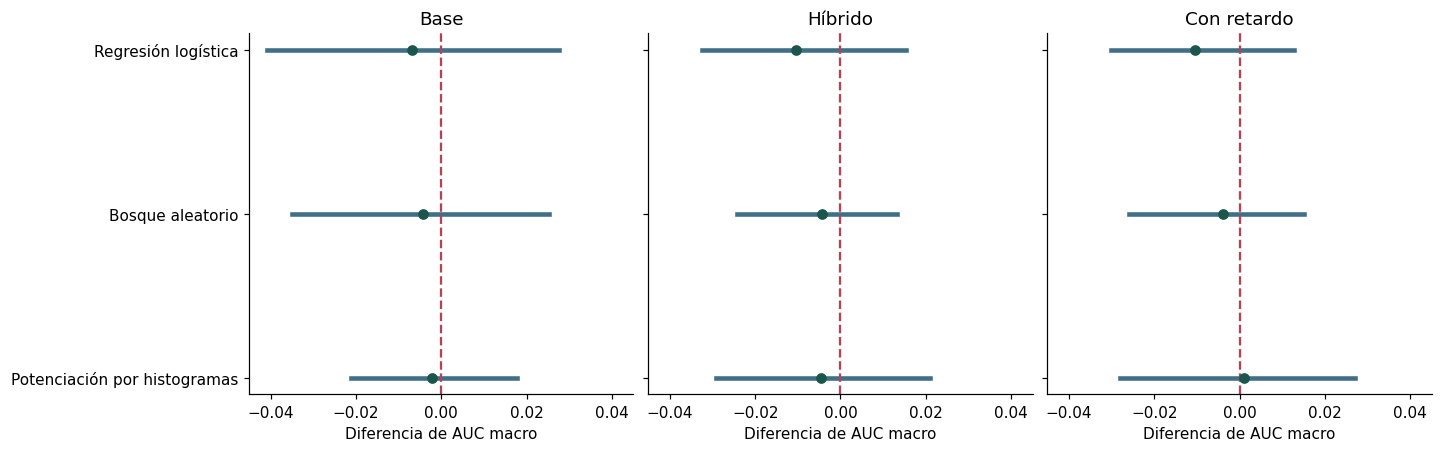

comparaciones  diferencias_positivas  \
approach     reference                                            
deduplicated reference                 9                      2   
enhanced     deduplicated              9                      1   
macro        enhanced                  9                      0   
tuned        macro                     9                      2   
             reference                 9                      1   
window_3y    deduplicated              9                      0   
window_5y    deduplicated              9                      4   

                           intervalos_positivos  intervalos_negativos  
approach     reference                                                 
deduplicated reference                        1                     0  
enhanced     deduplicated                     0                     0  
macro        enhanced                         0                     0  
tuned        macro                            0                     0  
             reference                        0                     0  
window_3y    deduplicated                     0                     0  
window_5y    deduplicated                     0                     0

**Comparación principal:** las tres filas híbridas; las demás son análisis secundarios.

In [5]:
final = intervals[(intervals.approach == 'tuned') & (intervals.reference == 'reference') & (intervals.ticker == 'macro')]
display(final[['dataset_type', 'model_name', 'roc_auc', 'reference_auc', 'auc_delta', 'delta_low', 'delta_high']].round(5))
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True, layout='constrained')
bound = float(final[['delta_low', 'delta_high']].abs().max().max()) * 1.1
for ax, variant in zip(axes, variants):
    view = final[final.dataset_type == variant].set_index('model_name').reindex(list(models))
    for position, row in enumerate(view.itertuples()):
        ax.plot([row.delta_low, row.delta_high], [position, position], color='#416f88', linewidth=3)
        ax.scatter(row.auc_delta, position, color='#1b554b', zorder=3)
    ax.axvline(0, color='#b34458', linestyle='--')
    ax.set_yticks(range(len(models)), list(models.values()))
    ax.set_title(variants[variant])
    ax.set_xlabel('Diferencia de AUC macro')
    ax.set_xlim(-bound, bound)
axes[0].invert_yaxis()
plt.show()
mac = intervals[intervals.ticker == 'macro'].assign(positive=lambda x: x.delta_low > 0, negative=lambda x: x.delta_high < 0)
display(mac.groupby(['approach', 'reference']).agg(comparaciones=('auc_delta', 'size'), diferencias_positivas=('auc_delta', lambda x: (x > 0).sum()), intervalos_positivos=('positive', 'sum'), intervalos_negativos=('negative', 'sum')))
display(Markdown('**Comparación principal:** las tres filas híbridas; las demás son análisis secundarios.'))

## 6. Empresas, bloques y porcentaje de aciertos

Un promedio puede ocultar mejoras en unas empresas y empeoramientos en otras. Se muestran las mismas combinaciones para todos los activos, sin elegir un algoritmo ganador diferente para cada celda. La referencia mayoritaria se ajusta con el pasado completo de cada bloque y se mantiene común entre etapas.

In [6]:
hybrid = companies[(companies.dataset_type == 'hybrid') & (companies.model_name != 'dummy')]
display(hybrid.groupby(['ticker', 'approach']).roc_auc.mean().unstack('approach').reindex(columns=stages).rename(columns=names).round(4))
display(macro[(macro.approach.isin(['reference', 'tuned'])) & ((macro.dataset_type == 'hybrid') | (macro.model_name == 'dummy'))]
        [['approach', 'model_name', 'roc_auc', 'accuracy', 'balanced_accuracy', 'f1_macro', 'mcc']].round(4))
display(folds[(folds.scope == 'outer_fold') & (folds.dataset_type == 'hybrid') & (folds.approach.isin(['reference', 'tuned']))]
        [['approach', 'ticker', 'model_name', 'group', 'roc_auc', 'accuracy']].round(4))

approach,Referencia,Deduplicación,Ventana 3 años,Ventana 5 años,Sentimiento enriquecido,Selección macro,Ajuste ampliado
ticker,,,,,,,
AAPL,0.4738,0.4607,0.4795,0.4699,0.4771,0.4771,0.4768
MSFT,0.5072,0.5106,0.4683,0.5039,0.5002,0.5002,0.5051
NVDA,0.5462,0.5354,0.5098,0.5340,0.5249,0.5249,0.5160
TSLA,0.5048,0.5158,0.5229,0.5079,0.5164,0.5164,0.5081


,approach,model_name,roc_auc,accuracy,balanced_accuracy,f1_macro,mcc
30,reference,dummy,0.5000,0.5389,0.5000,0.3501,0.0000
34,reference,hist_gradient_boosting,0.5127,0.5163,0.5031,0.4888,0.0064
35,reference,logistic_regression,0.5000,0.5036,0.4994,0.4866,-0.0031
36,reference,random_forest,0.5112,0.5194,0.5076,0.4928,0.0139
40,tuned,dummy,0.5000,0.5389,0.5000,0.3501,0.0000
44,tuned,hist_gradient_boosting,0.5081,0.5122,0.5067,0.5046,0.0131
45,tuned,logistic_regression,0.4897,0.5009,0.4924,0.4864,-0.0152
46,tuned,random_forest,0.5069,0.5131,0.4937,0.4686,-0.0158


,approach,ticker,model_name,group,roc_auc,accuracy
545,reference,AAPL,hist_gradient_boosting,1.0,0.4596,0.5622
546,reference,AAPL,hist_gradient_boosting,2.0,0.4798,0.4946
547,reference,AAPL,hist_gradient_boosting,3.0,0.5270,0.5489
549,reference,MSFT,hist_gradient_boosting,1.0,0.4555,0.5189
550,reference,MSFT,hist_gradient_boosting,2.0,0.5683,0.5543
...,...,...,...,...,...,...
746,tuned,NVDA,random_forest,2.0,0.5188,0.5380
747,tuned,NVDA,random_forest,3.0,0.5020,0.4674
749,tuned,TSLA,random_forest,1.0,0.5432,0.4865
750,tuned,TSLA,random_forest,2.0,0.5440,0.4891


## 7. Qué ha elegido la validación interna

Los algoritmos de árboles prueban veinte candidatos en total cada uno, no veinte por ventana. Incluyen las dos configuraciones originales y dieciocho candidatos adicionales con semilla fija. Regresión logística mantiene dos valores de C y compara tres ventanas: seis candidatos. El umbral sigue en 0,5.

Una puntuación interna mayor no garantiza una mejora externa. Tampoco el número de veces que se elige una ventana identifica su superioridad fuera de estas particiones.

In [7]:
display(selected[(selected.approach == 'tuned') & (selected.model_name != 'dummy')]
        [['outer_fold', 'dataset_type', 'model_name', 'window_years', 'inner_score', 'params']])
candidate_rows = [{'algoritmo': models[model], 'candidato': i, 'ventana': item['years'] or 'Todo', 'parámetros': item['params']}
                  for model, configs in manifest['config']['candidates']['tuned'].items() for i, item in enumerate(configs)]
display(pd.DataFrame(candidate_rows))

,outer_fold,dataset_type,model_name,window_years,inner_score,params
181,1,base,logistic_regression,5,0.511369,"{""model__C"": 0.1}"
182,1,base,random_forest,3,0.510172,"{""model__max_depth"": 8, ""model__max_features"":..."
183,1,base,hist_gradient_boosting,all,0.510360,"{""model__early_stopping"": false, ""model__l2_re..."
184,1,hybrid,logistic_regression,5,0.517908,"{""model__C"": 0.1}"
185,1,hybrid,random_forest,all,0.517539,"{""model__max_depth"": 4, ""model__min_samples_le..."
186,1,hybrid,hist_gradient_boosting,5,0.516592,"{""model__early_stopping"": false, ""model__l2_re..."
187,1,lag_1,logistic_regression,all,0.509775,"{""model__C"": 0.1}"
188,1,lag_1,random_forest,3,0.508340,"{""model__max_depth"": 4, ""model__max_features"":..."
189,1,lag_1,hist_gradient_boosting,5,0.508462,"{""model__early_stopping"": false, ""model__l2_re..."
191,2,base,logistic_regression,3,0.515286,"{""model__C"": 0.1}"


,algoritmo,candidato,ventana,parámetros
0,Regresión logística,0,Todo,{'model__C': 0.1}
1,Regresión logística,1,Todo,{'model__C': 10.0}
2,Regresión logística,2,3,{'model__C': 0.1}
3,Regresión logística,3,3,{'model__C': 10.0}
4,Regresión logística,4,5,{'model__C': 0.1}
5,Regresión logística,5,5,{'model__C': 10.0}
6,Bosque aleatorio,0,Todo,"{'model__n_estimators': 100, 'model__max_depth..."
7,Bosque aleatorio,1,Todo,"{'model__n_estimators': 100, 'model__max_depth..."
8,Bosque aleatorio,2,Todo,"{'model__n_estimators': 100, 'model__max_depth..."
9,Bosque aleatorio,3,3,"{'model__n_estimators': 100, 'model__max_depth..."


## 8. Verificaciones de las tablas

Estas comprobaciones recalculan el AUC por empresa y comprueban que todos los enfoques comparten filas, etiquetas y bloques. La reproducción de los modelos guardados y las pruebas del código se documentan en el informe; los modelos no son necesarios para leer este cuaderno.

In [8]:
keys = ['ticker', 'Date', 'dataset_type', 'model_name', 'outer_fold']
assert not predictions.duplicated(['approach'] + keys).any()
reference = predictions[predictions.approach == 'reference'].sort_values(keys).reset_index(drop=True)
for stage in stages:
    frame = predictions[predictions.approach == stage].sort_values(keys).reset_index(drop=True)
    pd.testing.assert_frame_equal(frame[keys + ['target']], reference[keys + ['target']])
    assert (frame.prediction == (frame.probability >= 0.5)).all()
for key, frame in predictions.groupby(['approach', 'dataset_type', 'model_name', 'ticker']):
    a, v, m, t = key
    recorded = companies[(companies.approach == a) & (companies.dataset_type == v) & (companies.model_name == m) & (companies.ticker == t)].roc_auc.item()
    assert np.isclose(recorded, roc_auc_score(frame.target, frame.probability), atol=1e-12)
display(Markdown('Verificadas las huellas de los informes, las fronteras, el emparejamiento y el AUC por empresa.'))

Verificadas las huellas de los informes, las fronteras, el emparejamiento y el AUC por empresa.

## 9. Interpretación y límites

**Resultado de esta ejecución:** la combinación completa no mejora el AUC macro medio de los tres algoritmos. El híbrido pasa de 0,5080 a 0,5015 y los tres contrastes híbridos principales tienen diferencias negativas con intervalos que incluyen cero. La selección macro elige los mismos parámetros que el criterio agrupado con la rejilla pequeña; no cambia las predicciones. La búsqueda ampliada mejora la puntuación interna en 23 de 27 ajustes, sin trasladar esa mejora al resultado externo general.

La deduplicación con potenciación por histogramas y retardo alcanza el máximo descriptivo, 0,5172 de AUC macro. Su diferencia frente a la referencia es +0,014758, con intervalo [0,000080; 0,029403], pero el intervalo de su propio AUC incluye 0,5. Es el único contraste macro nominalmente positivo entre 63 y su límite inferior está muy cerca de cero: no constituye evidencia robusta para elegir un ganador.

La ronda debe juzgarse por sus contrastes prefijados, no por el máximo de una tabla. La depuración puede reducir repeticiones, pero también eliminar actualizaciones legítimas; una ventana corta puede adaptarse mejor o perder información; más variables y candidatos pueden mejorar el ajuste interno sin generalizar.

Los intervalos no corrigen la multiplicidad y el histórico ya había sido consultado. AUC, exactitud y MCC no prueban rentabilidad. Una conclusión confirmatoria requiere fijar una regla de selección y evaluarla en fechas nuevas. El [informe completo](../reports/experiments/first-round-full-20260916/analysis.md) recoge la lectura específica de esta ejecución, incluidos resultados desfavorables.